<a href="https://colab.research.google.com/github/XAI-CLASS/Regression_models_XAI/blob/main/telco_customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Telco Customer Churn Prediction

##  Objective

Predict customers who are likely to churn and identify high-risk
customers for targeted retention strategies.

##  Project Workflow

1. Dataset loading and cleaning.
2. EDA relevant to logistic regression assumptions.
3. Logistic regression model code.
4. Model performance evidence.
5. Coefficient or odds-ratio interpretation in markdown.
6. At least one limitation of using logistic regression for churn.


##  Key Results

**Best Model:** Logistic Regression

**ROC-AUC:** 84.22%

**Accuracy:** 80.70%




In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(
    '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
)

In [4]:
df.drop("customerID", axis=1, inplace=True)

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isna().sum()
df[df["TotalCharges"].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


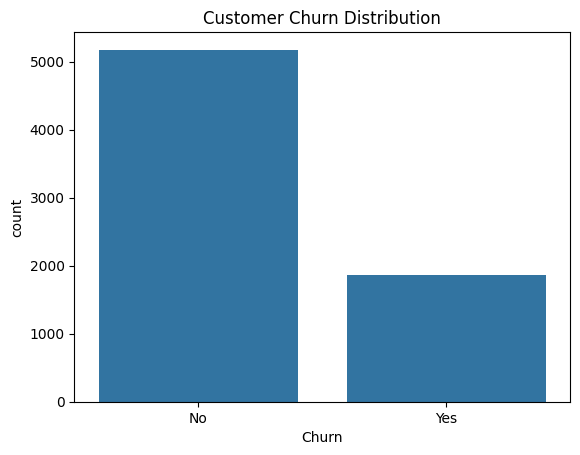

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Gender-churn correlation

In [9]:
pd.crosstab(df['gender'],df['Churn'], normalize='index')*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


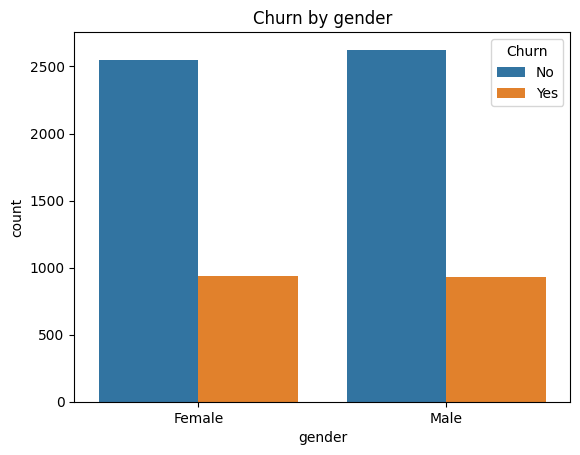

In [10]:
sns.countplot(data=df,x='gender',hue='Churn')
plt.title('Churn by gender')
plt.show()

# contract-churn correlation

In [11]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


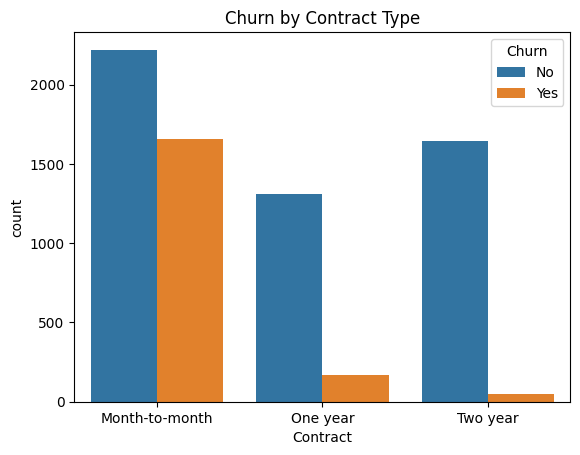

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

# Tenure-churn correlation

In [12]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

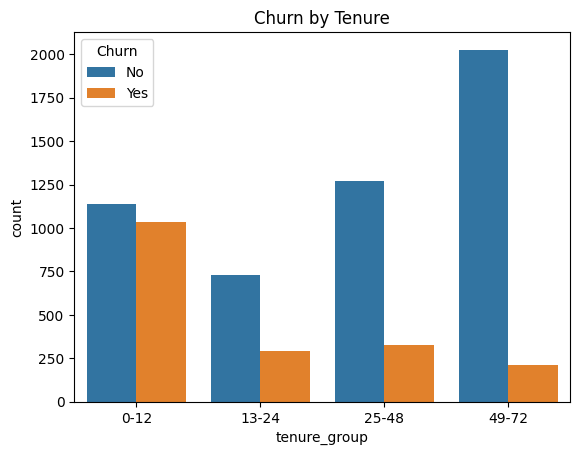

In [13]:
pd.crosstab(df["tenure_group"], df["Churn"], normalize="index") * 100
sns.countplot(data=df, x="tenure_group", hue="Churn")
plt.title("Churn by Tenure")
plt.show()

# Monthly Charges

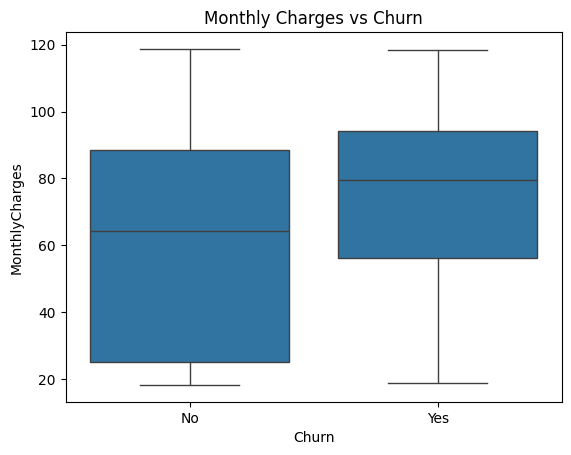

In [14]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()

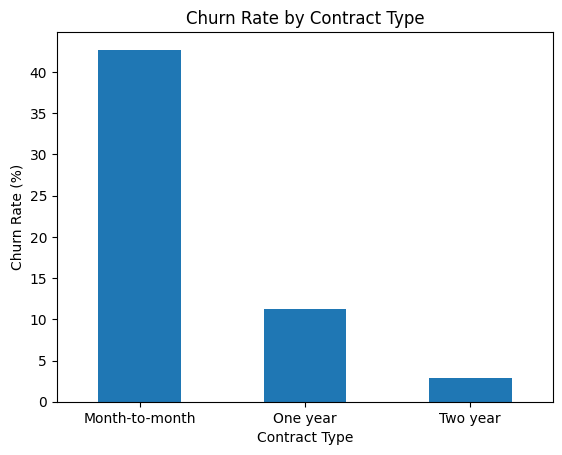

In [15]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn["Yes"].plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.show()

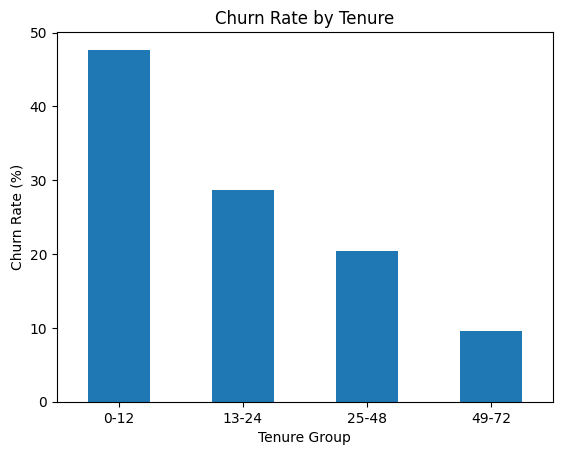

In [16]:
tenure_churn=pd.crosstab(df['tenure_group'],df['Churn'],normalize="index")*100
tenure_churn['Yes'].plot(kind='bar')
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group")
plt.title("Churn Rate by Tenure")
plt.xticks(rotation=0)
plt.show()

In [17]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


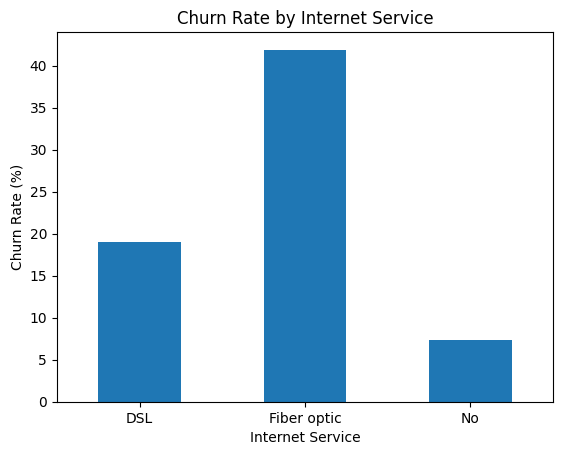

In [18]:
internet_churn["Yes"].plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Internet Service")
plt.title("Churn Rate by Internet Service")
plt.xticks(rotation=0)
plt.show()

In [19]:
features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

for feature in features:
    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100

    print("\n", feature)
    print(churn_rate["Yes"])


 OnlineSecurity
OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Yes, dtype: float64

 OnlineBackup
OnlineBackup
No                     39.928756
No internet service     7.404980
Yes                    21.531494
Name: Yes, dtype: float64

 DeviceProtection
DeviceProtection
No                     39.127625
No internet service     7.404980
Yes                    22.502064
Name: Yes, dtype: float64

 TechSupport
TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Yes, dtype: float64


In [20]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn["Yes"].sort_values(ascending=False))

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64


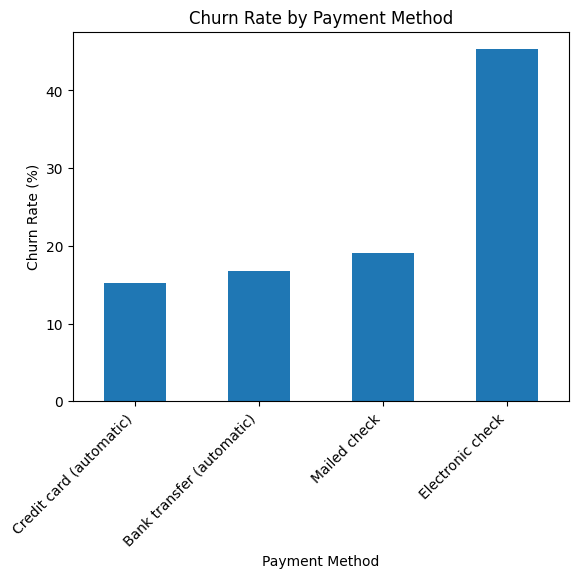

In [21]:
payment_churn["Yes"].sort_values().plot(kind="bar")

plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=45, ha="right")
plt.show()

In [22]:
pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [23]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [25]:
df_model = df.copy()

In [26]:
df_model.drop('tenure_group',axis=1,inplace=True)
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [28]:
df_model["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [29]:
df_model.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


# Logistic regression

In [30]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",drop="first"), categorical_cols)
    ]
)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [36]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [37]:
y_pred = logistic_model.predict(X_test)

In [38]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8069552874378992
Precision: 0.660377358490566
Recall   : 0.5614973262032086
F1 Score : 0.6069364161849711
ROC-AUC  : 0.8421710713270816


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



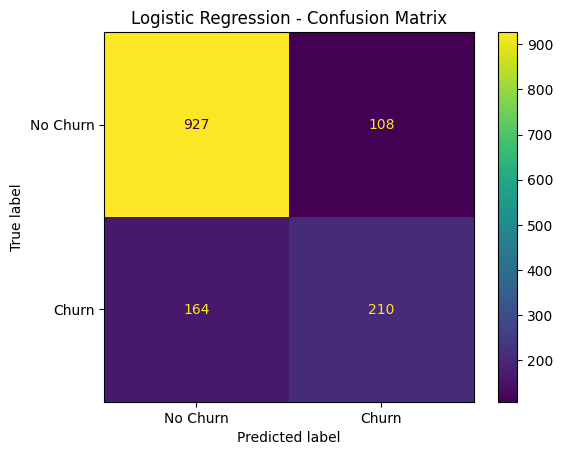

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [53]:
# Ensure the model is fitted before accessing coefficients
logistic_model.fit(X_train, y_train)

feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [54]:
# Display top 15 positive coefficients
print("Top 15 Positive Coefficients (Increased Churn Likelihood):")
display(coef_df.sort_values("Coefficient", ascending=False).head(15))

Top 15 Positive Coefficients (Increased Churn Likelihood):


,Feature,Coefficient
10,cat__InternetService_Fiber optic,1.182298
3,num__TotalCharges,0.523110
28,cat__PaymentMethod_Electronic check,0.383863
21,cat__StreamingTV_Yes,0.377500
23,cat__StreamingMovies_Yes,0.376065
26,cat__PaperlessBilling_Yes,0.371284
9,cat__MultipleLines_Yes,0.362275
29,cat__PaymentMethod_Mailed check,0.075442
0,num__SeniorCitizen,0.054651
17,cat__DeviceProtection_Yes,0.035237


In [55]:
# Display top 15 negative coefficients
print("Top 15 Negative Coefficients (Decreased Churn Likelihood):")
display(coef_df.sort_values("Coefficient", ascending=True).head(15))

Top 15 Negative Coefficients (Decreased Churn Likelihood):


,Feature,Coefficient
25,cat__Contract_Two year,-1.326384
1,num__tenure,-1.250481
24,cat__Contract_One year,-0.686597
7,cat__PhoneService_Yes,-0.505143
2,num__MonthlyCharges,-0.470779
13,cat__OnlineSecurity_Yes,-0.349623
19,cat__TechSupport_Yes,-0.297591
8,cat__MultipleLines_No phone service,-0.256658
6,cat__Dependents_Yes,-0.224945
14,cat__OnlineBackup_No internet service,-0.173381


### Interpretation of Logistic Regression Coefficients

For logistic regression, coefficients represent the change in the log-odds of the outcome for a one-unit increase in the predictor variable, holding other variables constant. A positive coefficient indicates that as the feature value increases, the log-odds of churn increase, meaning a higher probability of churn. Conversely, a negative coefficient indicates a lower probability of churn.

From the sorted coefficients, we can observe that:

*   **High positive coefficients** (e.g., `InternetService_Fiber optic`, `TotalCharges`, `PaymentMethod_Electronic check`, `StreamingTV_Yes`, `StreamingMovies_Yes`, `PaperlessBilling_Yes`, `MultipleLines_Yes`) are associated with an increased likelihood of churn. For instance, customers with fiber optic internet, higher total charges, using electronic checks, or having streaming services are more likely to churn.
*   **High negative coefficients** (e.g., `Contract_Two year`, `tenure`, `Contract_One year`, `PhoneService_Yes`, `MonthlyCharges`) are associated with a decreased likelihood of churn. This suggests that customers with longer contracts, longer tenure, or lower monthly charges are less likely to churn.

## threshold tuning

In [48]:
import numpy as np

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision_score(y_test, y_pred_threshold):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_threshold):.3f} | "
        f"F1: {f1_score(y_test, y_pred_threshold):.3f}"
    )

Threshold: 0.3 | Precision: 0.519 | Recall: 0.754 | F1: 0.615
Threshold: 0.4 | Precision: 0.571 | Recall: 0.668 | F1: 0.616
Threshold: 0.5 | Precision: 0.660 | Recall: 0.561 | F1: 0.607
Threshold: 0.6 | Precision: 0.718 | Recall: 0.401 | F1: 0.515
Threshold: 0.7 | Precision: 0.742 | Recall: 0.184 | F1: 0.296


### Interpreting Threshold Tuning Results

When dealing with classification problems like churn prediction, simply using a default probability threshold of 0.5 (where probabilities >= 0.5 are classified as positive, and < 0.5 as negative) might not always be optimal. Different business objectives might require prioritizing different metrics. Threshold tuning helps us find a balance or optimize for a specific metric.

Let's break down what these metrics mean in the context of churn prediction:

*   **Precision**: Out of all customers *predicted* to churn, how many actually churned? High precision means fewer false positives (we don't incorrectly flag too many loyal customers as churn risks).
*   **Recall**: Out of all customers who *actually* churned, how many did we correctly identify? High recall means fewer false negatives (we catch most of the actual churners).
*   **F1-Score**: The harmonic mean of Precision and Recall. It provides a single score that balances both metrics. It's particularly useful when you have an uneven class distribution (like churn, which is often imbalanced).

**Analysis of the provided results:**

*   **Threshold = 0.5 (Default)**:
    *   Precision: 0.660
    *   Recall: 0.561
    *   F1-Score: 0.607
    At the default threshold, the model has a decent balance, but the recall is lower, meaning it misses a significant portion of actual churners.

*   **Lowering the Threshold (e.g., 0.3)**:
    *   **Precision: 0.519** (decreases)
    *   **Recall: 0.754** (increases significantly)
    *   F1-Score: 0.615 (slightly increases)
    By lowering the threshold to 0.3, we become more sensitive to predicting churn. This means we identify many more actual churners (higher recall), but at the cost of flagging more non-churners as churn risks (lower precision). This could be beneficial if the cost of missing a churner is very high.

*   **Increasing the Threshold (e.g., 0.7)**:
    *   **Precision: 0.742** (increases significantly)
    *   **Recall: 0.184** (decreases significantly)
    *   F1-Score: 0.296 (decreases)
    Increasing the threshold makes the model more conservative in predicting churn. It predicts churn only when it's very confident. This leads to very high precision (when it predicts churn, it's usually right), but it misses most actual churners (very low recall). This might be suitable if the cost of incorrectly targeting a loyal customer is extremely high.

**Key Takeaway:**

There's a clear **trade-off between Precision and Recall**. As one increases, the other tends to decrease. The `F1-Score` gives a balanced view. In churn prediction, businesses often prioritize **Recall** to ensure they identify as many potential churners as possible, even if it means a few false positives. This allows them to proactively engage with at-risk customers. For example, a threshold of **0.3** significantly boosts recall (from 0.561 to 0.754) with only a moderate decrease in precision, resulting in a slightly better F1-score as well. This might be a more desirable operating point for a churn prediction model if the goal is to maximize the identification of churning customers for intervention.

### Limitations of Logistic Regression for Churn Prediction

While logistic regression is a powerful and interpretable model, it has certain limitations, especially in the context of churn prediction:

*   **Assumes Linearity**: Logistic regression assumes a linear relationship between the independent variables and the log-odds of the dependent variable. Real-world relationships in customer behavior might be more complex and non-linear, which could be better captured by other models.
*   **Assumes Independence of Predictors**: It assumes that the independent variables are not highly correlated with each other (minimal multicollinearity). While `drop='first'` helps with perfect multicollinearity in one-hot encoded features, significant correlations between other predictors can still affect coefficient estimates and model stability.
*   **Sensitive to Outliers**: Logistic regression can be sensitive to outliers in the data, which may disproportionately influence the model's coefficients and predictions.